In [194]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
import json
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "results_experiments"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments


In [195]:
load_dir = DATA_ROOT / "composition_analysis" / "run_004"

In [196]:
def load_joint_experiment(load_dir):
    load_dir = Path(load_dir)

    with open(load_dir / "config.json", "r") as f:
        config = json.load(f)

    with open(load_dir / "results.pkl", "rb") as f:
        results_by_experiment = pickle.load(f)

    with open(load_dir / "meta.json", "r") as f:
        meta = json.load(f)

    return config, results_by_experiment, meta

In [197]:
config, results_by_experiment, meta = load_joint_experiment(load_dir)

print(f"""
Experiment summary
------------------
Hidden dim   : {config['hidden_dim']}
Max epochs   : {config['train_config']['max_epochs']}
Learning rate: {config['train_config']['lr']}
Batch size   : {config['train_config']['batch_size']}
""")


Experiment summary
------------------
Hidden dim   : 256
Max epochs   : 2000
Learning rate: 0.001
Batch size   : 128



In [199]:
plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


exclude = {"GIN+degree"}

family_order = [
    f
    for exp_results in results_by_experiment.values()
    for f in exp_results.keys()
    if f not in exclude
]

# remove duplicates while preserving order
family_order = list(dict.fromkeys(family_order))
cmap = plt.get_cmap("tab10")
family_colors = {
    family: cmap(i % 10)
    for i, family in enumerate(family_order)
}

In [200]:
selected_marker_names = ["LGR5", "AldoB", "Serotonin", "Lysozyme"]
name_to_idx = {n: i for i, n in enumerate(config["marker_names"])}
selected_idx = [name_to_idx[n] for n in selected_marker_names]

exp1_original


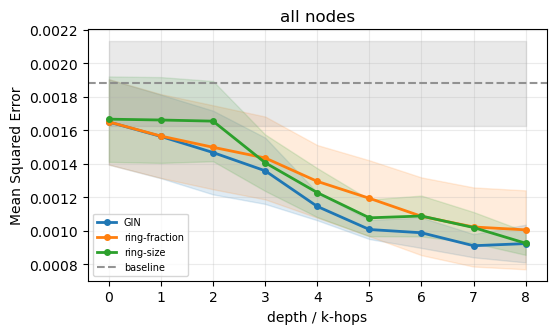

exp2_center_preserving_permuted


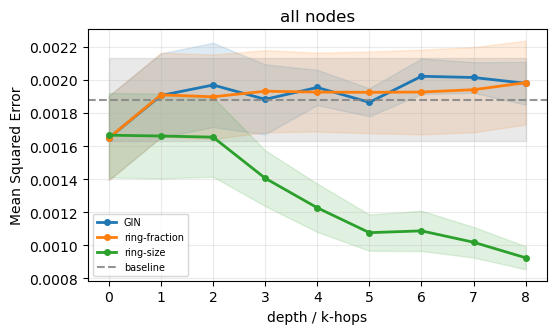

exp3_ring_preserving_permuted


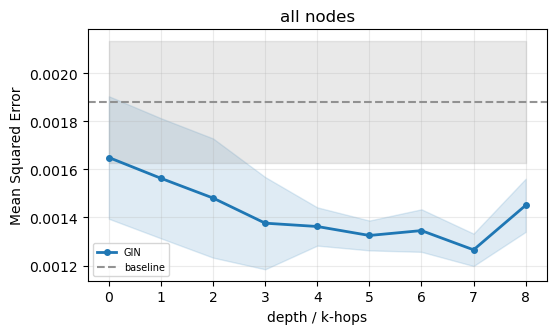

In [203]:
from src.plotting.depth_scan import plot_markerwise_metric_vs_depth, plot_all_aggregates_metric_vs_depth

for name, res in results_by_experiment.items():
    print(name)

    fig, axes = plot_all_aggregates_metric_vs_depth(
        res,
        config["depths"],
        aggregate_keys=("all_nodes",),
        metric_key="mse_model",
        sem_key="sem_mse_model",
        baseline_key="mse_base",
        baseline_sem_key="sem_mse_base",
        ylabel="Mean Squared Error",
        title="",
        family_order=family_order,
        family_colors=family_colors,
    )

    save_path = load_dir / "figures" / (name + "_mse_vs_depth.pdf")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight", transparent=True)

    plt.show()


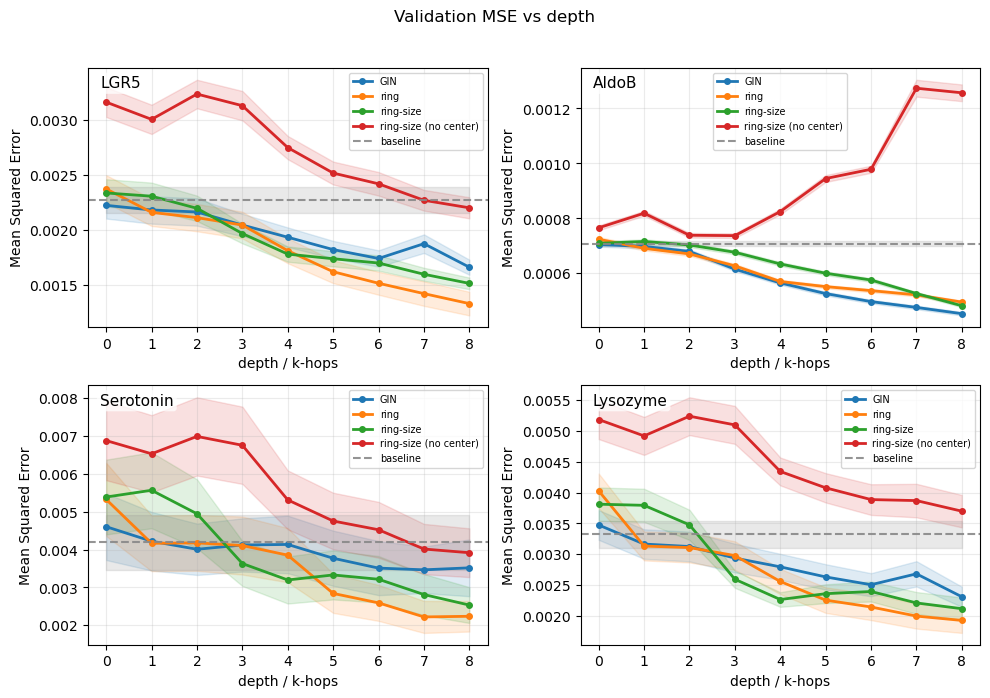

In [ ]:

for name, res in results_by_experiment.items():

    fig, axes = plot_markerwise_metric_vs_depth(
        all_results=res,
        depths=config["depths"],
        marker_names=config["marker_names"],
        selected_idx=selected_idx,
        metric_key="mse_model",
        sem_key="sem_mse_model",
        baseline_key="mse_base",
        baseline_sem_key="sem_mse_base",
        ylabel="Mean Squared Error",
        title="Validation MSE vs depth",
        family_order=family_order,
        family_colors=family_colors,
    )

    save_path = load_dir / "figures" / (name + "_mse_vs_depth_markerwise.pdf")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight", transparent=True)

    plt.show()

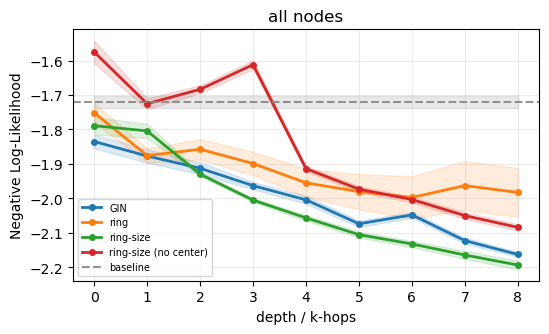

In [ ]:
for name, res in results_by_experiment.items():

    fig, axes = plot_all_aggregates_metric_vs_depth(
        res,
        config["depths"],
        aggregate_keys=("all_nodes",),
        metric_key="nll_model",
        sem_key="sem_nll_model",
        baseline_key="nll_base",
        baseline_sem_key="sem_nll_base",
        ylabel="Negative Log-Likelihood",
        title="",
        family_order=family_order,
        family_colors=family_colors,
    )

    save_path = load_dir / "figures" / (name + "_NLL_vs_depth.pdf")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight", transparent=True)

    plt.show()

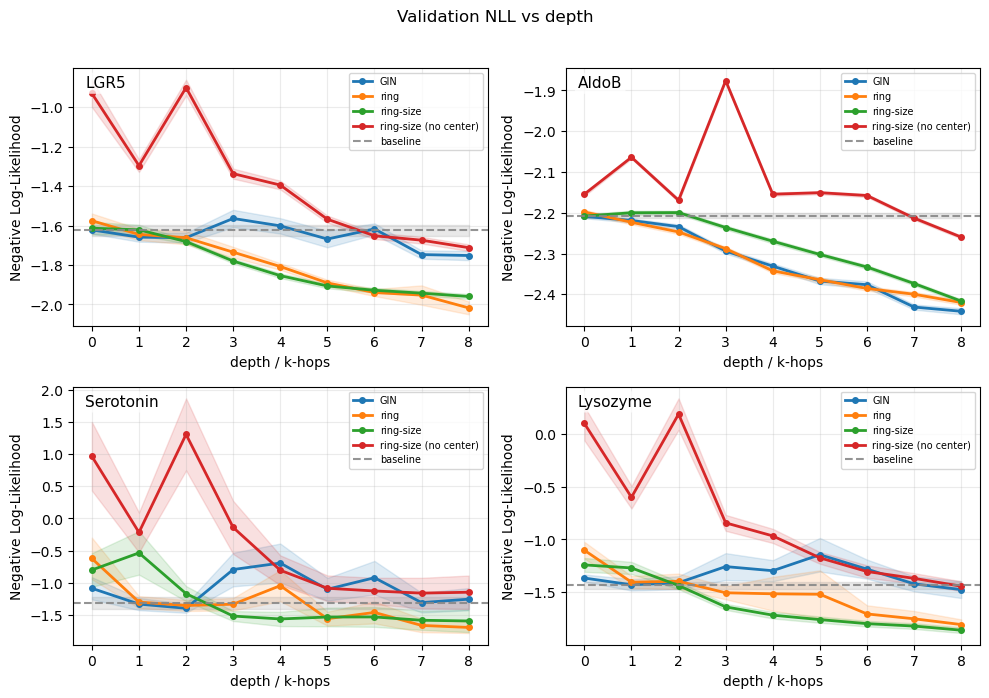

In [ ]:
for name, res in results_by_experiment.items():

    fig, axes = plot_markerwise_metric_vs_depth(
        all_results=res,
        depths=config["depths"],
        marker_names=config["marker_names"],
        selected_idx=selected_idx,
        metric_key="nll_model",
        sem_key="sem_nll_model",
        baseline_key="nll_base",
        baseline_sem_key="sem_nll_base",
        ylabel="Negative Log-Likelihood",
        title="Validation NLL vs depth",
        family_order=family_order,
        family_colors=family_colors,
    )

    save_path = load_dir / "figures" / (name + "_NLL_vs_depth_markerwise.pdf")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight", transparent=True)

    plt.show()

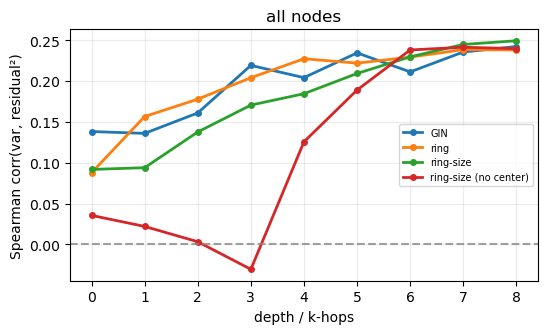

In [ ]:
for name, res in results_by_experiment.items():

    fig, axes = plot_all_aggregates_metric_vs_depth(
        res,
        config["depths"],
        aggregate_keys=("all_nodes",),
        metric_key="rho",
        baseline_hline=0.0,
        ylabel="Spearman corr(var, residual²)",
        title="",
        family_order=family_order,
        family_colors=family_colors,
    )

    save_path = load_dir / "figures" / (name + "_corr_vs_depth.pdf")
    save_path.parent.mkdir(parents=True, exist_ok=True)

    fig.savefig(save_path, bbox_inches="tight", transparent=True)

    plt.show()